# B6 - Supervised pretraining: does a warm start help?

raccoon spent a whole track on this: pretrain the network on existing knowledge
(wildbg rollouts, GNUBG analysis) before self-play. Here we do the toy version:
pretrain on **exact solver labels** for DiceRace, then compare self-play from the
warm start vs from scratch.

A key raccoon finding - *"a calibrated value is not a player"* - falls out naturally.

In [1]:
import numpy as np, torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from azl.games.dice_race import DiceRace
from azl.network import net_for_game
from azl.solvers import ExactSolver, solver_dataset, enumerate_states
from azl.metrics import value_mae_vs_solver, optimal_action_accuracy
from azl.evaluate import mcts_player
from azl.trainer import Coach, CoachConfig

solver = ExactSolver()
obs, values, policies, states = solver_dataset(DiceRace.start(), solver)
print("supervised states:", len(states))
grade = [states[i] for i in np.random.default_rng(0).choice(len(states), 400, replace=False)]

supervised states: 3285


In [2]:
# Pretrain BOTH heads on exact labels (value MSE + policy CE).
torch.manual_seed(0)
pre = net_for_game(DiceRace)
opt = torch.optim.Adam(pre.parameters(), lr=1e-3, weight_decay=1e-4)
X = torch.from_numpy(obs).float(); V = torch.from_numpy(values).float(); P = torch.from_numpy(policies).float()
for epoch in range(40):
    perm = torch.randperm(X.size(0))
    for i in range(0, X.size(0), 128):
        idx = perm[i:i+128]
        logits, value = pre(X[idx])
        loss = F.mse_loss(value, V[idx]) - (P[idx] * F.log_softmax(logits, 1)).sum(1).mean()
        opt.zero_grad(); loss.backward(); opt.step()
print("after pretraining: value MAE vs solver =", round(value_mae_vs_solver(pre, grade, solver), 3))
print("optimal-move accuracy (pretrained net + search) =",
      round(optimal_action_accuracy(mcts_player(pre, 40, rng=np.random.default_rng(1)), grade, solver), 3))

after pretraining: value MAE vs solver = 0.067


optimal-move accuracy (pretrained net + search) = 0.96


cold start: final optimal-move accuracy = 0.865


warm start (pretrained): final optimal-move accuracy = 0.938


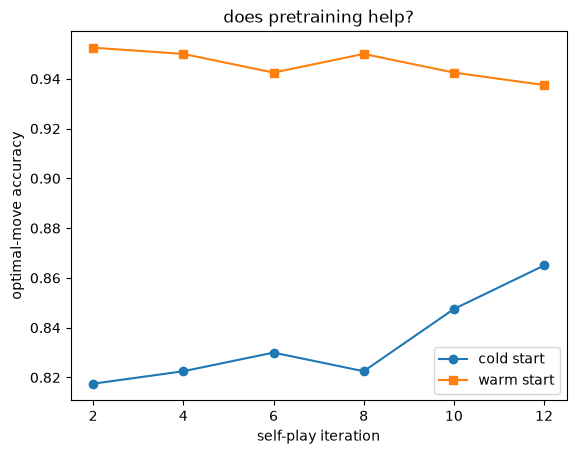

In [3]:
# Cold start vs warm start: self-play from scratch vs from the pretrained net.
def run(net, tag):
    coach = Coach(net=net, game_cls=DiceRace,
                  config=CoachConfig(games_per_iter=18, num_simulations=40, temp_threshold=4), seed=0)
    accs, its = [], []
    def cb(i, m, c):
        if i % 2: return
        a = optimal_action_accuracy(mcts_player(c.net, 40, rng=np.random.default_rng(i)), grade, solver)
        accs.append(a); its.append(i)
    coach.train(12, callback=cb, verbose=False)
    print(f"{tag}: final optimal-move accuracy = {accs[-1]:.3f}")
    return its, accs

import copy
torch.manual_seed(0); cold = run(net_for_game(DiceRace), "cold start")
warm = run(copy.deepcopy(pre), "warm start (pretrained)")
plt.plot(*cold, "o-", label="cold start"); plt.plot(*warm, "s-", label="warm start")
plt.xlabel("self-play iteration"); plt.ylabel("optimal-move accuracy"); plt.legend(); plt.title("does pretraining help?"); plt.show()

### What to notice
- The **warm start begins much higher** and stays ahead - pretraining transferred
  real knowledge.
- But notice the *value-only* lesson: if you pretrain **only the value head**
  (`loss = F.mse_loss(...)` and drop the policy term), the agent barely improves at
  first, because MCTS with a *random policy prior* can't find good moves even with a
  perfect value. That is raccoon's **"a calibrated value is not a player"** (its
  pretraining Stage 1 lost 0-200 to GNUBG). Try it!

### Maps to raccoon
This mirrors raccoon's pretraining track: `solver_dataset` is the toy of its wildbg /
GNUBG label sets, and the warm-start-then-self-play recipe is `pretrain.py` +
`train.py --resume`.